In [1]:
import pandas as pd

retail_raw = pd.read_csv('online_retail_II.csv')
retail = retail_raw.dropna().copy(deep=True).loc[:, 'Quantity':'Country']

In [2]:
retail.head(5)

,Quantity,InvoiceDate,Price,Customer ID,Country
0,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Quantity     824364 non-null  int64  
 1   InvoiceDate  824364 non-null  object 
 2   Price        824364 non-null  float64
 3   Customer ID  824364 non-null  float64
 4   Country      824364 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 37.7+ MB


In [4]:
retail.InvoiceDate = pd.to_datetime(retail.InvoiceDate)
retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Quantity     824364 non-null  int64         
 1   InvoiceDate  824364 non-null  datetime64[ns]
 2   Price        824364 non-null  float64       
 3   Customer ID  824364 non-null  float64       
 4   Country      824364 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 37.7+ MB


In [5]:
retail_group = retail.groupby(['Customer ID', 'Country'], as_index=False).agg(
    Total_Price=('Price', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Start_InvoiceDate=('InvoiceDate', 'min'),
    End_InvoiceDate=('InvoiceDate', 'max')
)
retail_group.head(5)

,Customer ID,Country,Total_Price,Total_Quantity,Start_InvoiceDate,End_InvoiceDate
0,12346.0,United Kingdom,580.44,52,2009-12-14 08:34:00,2011-01-18 10:17:00
1,12347.0,Iceland,644.16,3286,2010-10-31 14:20:00,2011-12-07 15:52:00
2,12348.0,Finland,193.10,2714,2010-09-27 14:59:00,2011-09-25 13:13:00
3,12349.0,Italy,1504.59,1619,2009-12-04 12:49:00,2011-11-21 09:51:00
4,12350.0,Norway,65.30,197,2011-02-02 16:01:00,2011-02-02 16:01:00


In [6]:
import numpy as np

neg_total_quantity = retail_group[retail_group['Total_Quantity'] <= 0]
neg_total_price = retail_group[retail_group['Total_Price'] <= 0]
neg_total = pd.concat([neg_total_price, neg_total_quantity])
retail_filtered = retail_group.drop(index=neg_total.index)

In [7]:
retail_filtered[['Total_Price', 'Total_Quantity']].describe()

,Total_Price,Total_Quantity
count,5853.000000,5853.000000
mean,490.144717,1746.776867
std,1788.928067,8624.028912
min,0.170000,1.000000
25%,67.810000,189.000000
50%,175.240000,487.000000
75%,461.370000,1360.000000
max,71343.060000,365220.000000


<Axes: ylabel='count'>

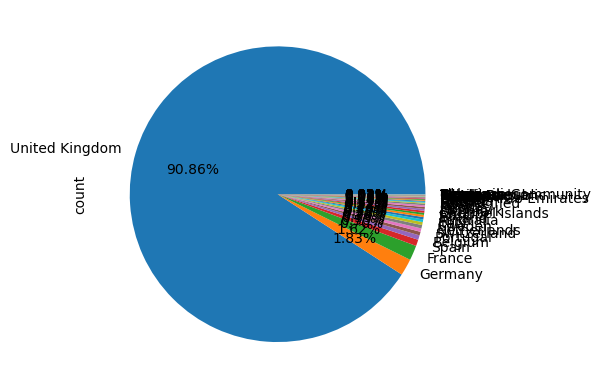

In [8]:
import matplotlib.pyplot as plt

retail_filtered['Country'].value_counts().plot.pie(autopct="%.2f%%")

In [9]:
import numpy as np

retail_log1p = retail_filtered.copy(deep=True)
retail_log1p['Total_Price'] = np.log1p(retail_log1p['Total_Price'])
retail_log1p['Total_Quantity'] = np.log1p(retail_log1p['Total_Quantity'])
retail_log1p[['Total_Price', 'Total_Quantity']].describe()

,Total_Price,Total_Quantity
count,5853.000000,5853.000000
mean,5.135475,6.207653
std,1.461961,1.490265
min,0.157004,0.693147
25%,4.231349,5.247024
50%,5.171847,6.190315
75%,6.136365,7.215975
max,11.175269,12.808258


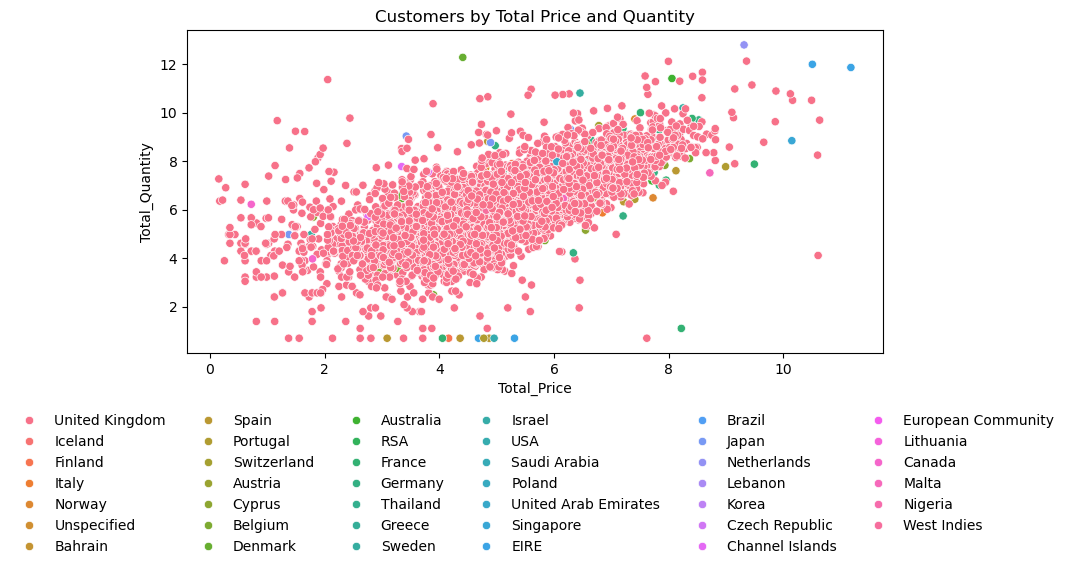

In [10]:
import seaborn as sns

plt.figure(figsize=(10, 6))
palette = sns.color_palette('husl', retail_filtered.Country.nunique())

sns.scatterplot(data=retail_log1p, x='Total_Price', y='Total_Quantity', hue='Country', palette=palette)
plt.title('Customers by Total Price and Quantity')

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=6,
    frameon=False,
)

plt.tight_layout()
plt.show()

<Axes: ylabel='count'>

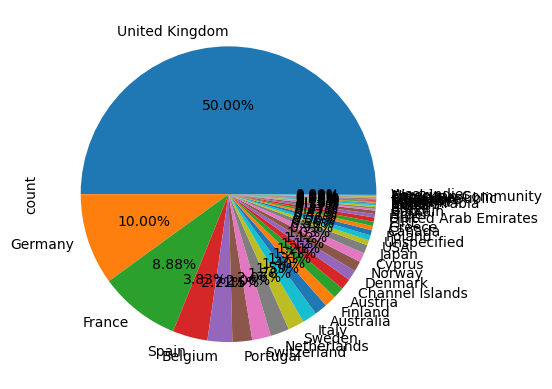

In [32]:
uk_data = retail_log1p[retail_log1p['Country'] == 'United Kingdom']
row_data = retail_log1p[retail_log1p['Country'] != 'United Kingdom']

country_counts = retail_log1p[retail_log1p['Country'] != 'United Kingdom']['Country'].value_counts()
avg_count = int(country_counts.sum())

uk_sampled = uk_data.sample(n=avg_count, random_state=42)
retail_sampled = pd.concat([uk_sampled, row_data], ignore_index=True)

retail_sampled['Country'].value_counts().plot.pie(autopct="%.2f%%")

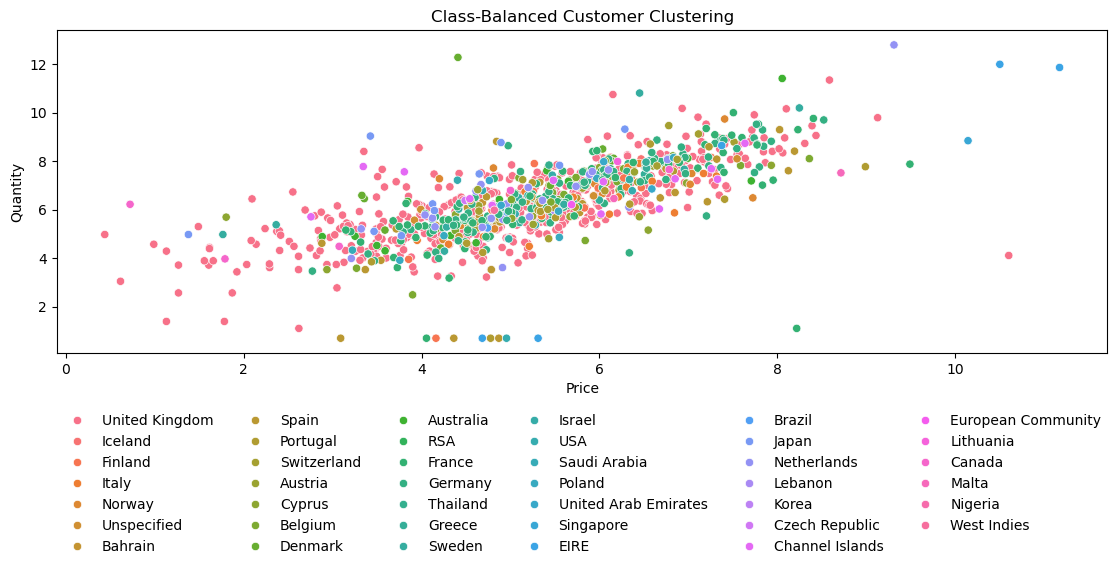

In [50]:
plt.figure(figsize=(12, 6))
palette = sns.color_palette('husl', retail_filtered.Country.nunique())

sns.scatterplot(data=retail_sampled, x='Total_Price', y='Total_Quantity', hue='Country', palette=palette)
plt.title('Class-Balanced Customer Clustering')
plt.xlabel('Price')
plt.ylabel('Quantity')

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=6,
    frameon=False,
)

plt.tight_layout()
plt.show()

In [34]:
retail_cp = retail_sampled.copy(deep=True)
retail_cp['Start_InvoiceDate_ts'] = retail_cp['Start_InvoiceDate'].astype('int64') // 10**9
retail_cp['End_InvoiceDate_ts'] = retail_cp['End_InvoiceDate'].astype('int64') // 10**9
retail_ts = retail_cp.drop(columns=['Start_InvoiceDate', 'End_InvoiceDate'])
retail_ts.head(5)

,Customer ID,Country,Total_Price,Total_Quantity,Start_InvoiceDate_ts,End_InvoiceDate_ts
0,17657.0,United Kingdom,2.818398,4.110874,1286290320,1286290320
1,17998.0,United Kingdom,5.411378,6.276643,1259672820,1290612900
2,16683.0,United Kingdom,4.162159,5.241747,1277375760,1277731200
3,14508.0,United Kingdom,6.480075,5.849325,1276779720,1321559280
4,13387.0,United Kingdom,4.951663,4.836282,1287410820,1287410820


In [35]:
encoded = pd.get_dummies(retail_ts, columns=['Country'], drop_first=True)
bool_cols = encoded.select_dtypes(include=['bool']).columns
encoded[bool_cols] = encoded[bool_cols].astype(int)
encoded.head(5)

,Customer ID,Total_Price,Total_Quantity,Start_InvoiceDate_ts,End_InvoiceDate_ts,Country_Austria,Country_Bahrain,Country_Belgium,Country_Brazil,Country_Canada,...,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_Thailand,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified,Country_West Indies
0,17657.0,2.818398,4.110874,1286290320,1286290320,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,17998.0,5.411378,6.276643,1259672820,1290612900,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,16683.0,4.162159,5.241747,1277375760,1277731200,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,14508.0,6.480075,5.849325,1276779720,1321559280,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,13387.0,4.951663,4.836282,1287410820,1287410820,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [36]:
from sklearn.preprocessing import RobustScaler

cols = encoded.loc[:, 'Customer ID':'End_InvoiceDate_ts'].columns
scalar = RobustScaler()
retail_scaled = encoded.copy(deep=True)
retail_scaled[cols] = scalar.fit_transform(retail_scaled[cols])
retail_scaled.head(5)

,Customer ID,Total_Price,Total_Quantity,Start_InvoiceDate_ts,End_InvoiceDate_ts,Country_Austria,Country_Bahrain,Country_Belgium,Country_Brazil,Country_Canada,...,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_Thailand,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified,Country_West Indies
0,1.349026,-1.400153,-1.063100,0.198936,-1.034829,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1.455339,0.085961,0.023660,-0.611398,-0.885159,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,1.045362,-0.630003,-0.495640,-0.072456,-1.331190,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.367264,0.698463,-0.190764,-0.090601,0.186366,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0.017771,-0.177515,-0.699098,0.233049,-0.996031,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

scores = []
X = retail_scaled
for k in range(2, 14):
    clusterer = KMeans(n_clusters=k, random_state=10)
    cluster_labels = clusterer.fit_predict(X)
    sil = silhouette_score(X, cluster_labels)
    ch = calinski_harabasz_score(X, cluster_labels)
    db = davies_bouldin_score(X, cluster_labels)
    scores.append((k, sil, ch, db))
    print(f"k={k} | Silhouette={sil:.3f} | Calinski-Harabasz={ch:.2f} | Davies-Bouldin={db:.3f} | Overall={(sil + ch + db) / 3}")

k=2 | Silhouette=0.225 | Calinski-Harabasz=388.50 | Davies-Bouldin=1.571 | Overall=130.09754962225827
k=3 | Silhouette=0.202 | Calinski-Harabasz=320.04 | Davies-Bouldin=1.684 | Overall=107.30939950087917
k=4 | Silhouette=0.196 | Calinski-Harabasz=284.46 | Davies-Bouldin=1.598 | Overall=95.4192494648666
k=5 | Silhouette=0.192 | Calinski-Harabasz=261.01 | Davies-Bouldin=1.468 | Overall=87.55712986141405
k=6 | Silhouette=0.178 | Calinski-Harabasz=236.09 | Davies-Bouldin=1.465 | Overall=79.2459678864061
k=7 | Silhouette=0.191 | Calinski-Harabasz=228.53 | Davies-Bouldin=1.548 | Overall=76.75519158968082
k=8 | Silhouette=0.187 | Calinski-Harabasz=204.24 | Davies-Bouldin=1.615 | Overall=68.6801712528976
k=9 | Silhouette=0.180 | Calinski-Harabasz=193.12 | Davies-Bouldin=1.642 | Overall=64.97893903720227
k=10 | Silhouette=0.180 | Calinski-Harabasz=185.36 | Davies-Bouldin=1.646 | Overall=62.39675594504025
k=11 | Silhouette=0.180 | Calinski-Harabasz=173.91 | Davies-Bouldin=1.634 | Overall=58.5755

In [ ]:
kmeans = KMeans(init='k-means++', n_clusters=2, random_state=42)
retail_sampled['cluster'] = kmeans.fit_predict(X)
# retail_scaled['cluster'] = kmeans.fit_predict(X)

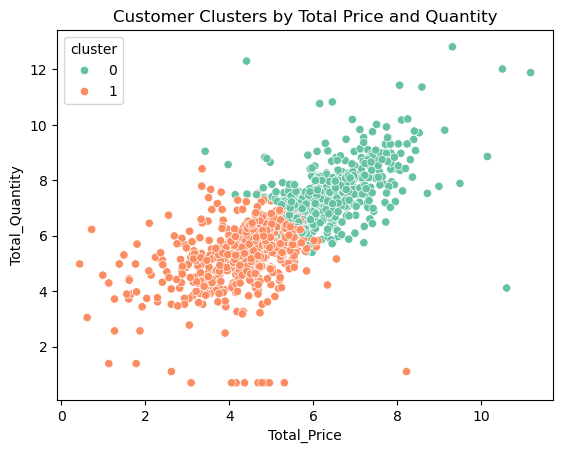

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=retail_sampled, x='Total_Price', y='Total_Quantity', hue='cluster', palette='Set2')
plt.title('Customer Clusters by Total Price and Quantity')
plt.show()

In [ ]:
# from sklearn.decomposition import PCA
#
# pca = PCA(n_components=2)
# components = pca.fit_transform(retail_clustered[feature_columns])
#
# plt.scatter(components[:, 0], components[:, 1], c=retail_clustered['cluster'], cmap='Set2')
# plt.xlabel('PC1')
# plt.ylabel('PC2')
# plt.title('Clusters visualized in 2D PCA space')
# plt.colorbar()
# plt.show()

,Customer ID,Country,Total_Price,Total_Quantity,Start_InvoiceDate,End_InvoiceDate,cluster
0,12346.0,United Kingdom,580.44,52,2009-12-14 08:34:00,2011-01-18 10:17:00,0
1,12347.0,Iceland,644.16,3286,2010-10-31 14:20:00,2011-12-07 15:52:00,2
2,12348.0,Finland,193.10,2714,2010-09-27 14:59:00,2011-09-25 13:13:00,6
3,12349.0,Italy,1504.59,1619,2009-12-04 12:49:00,2011-11-21 09:51:00,6
4,12350.0,Norway,65.30,197,2011-02-02 16:01:00,2011-02-02 16:01:00,2
...,...,...,...,...,...,...,...
5950,18283.0,United Kingdom,1719.75,1733,2010-02-19 17:16:00,2011-12-06 12:02:00,1
5951,18284.0,United Kingdom,116.09,493,2010-10-04 11:33:00,2010-10-06 12:31:00,7
5952,18285.0,United Kingdom,100.20,145,2010-02-17 10:24:00,2010-02-17 10:24:00,7
5953,18286.0,United Kingdom,306.55,592,2009-12-16 10:45:00,2010-08-20 11:57:00,7
